# Chapter 3: Classification

## MNIST

The MNIST dataset is widely considered the "Hello World" of Machine Learning. It contains 70,000 small images of digits handwritten by high school students and employees of the US Census Bureau. Each image is labeled with the digit it represents.

### Data Fetching and Inspection
We fetch the dataset using `fetch_openml`. A critical engineering point here is that the MNIST dataset returned by this function is already pre-split and strictly sorted into a training set (the first 60,000 images) and a test set (the last 10,000 images). 

Therefore, we do not need to apply a random split function. The training set is also pre-shuffled, ensuring that cross-validation folds will contain a balanced distribution of digits and preventing learning algorithms from being biased by sequences of similar instances.

In [3]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

In [4]:
X, y = mnist.data, mnist.target

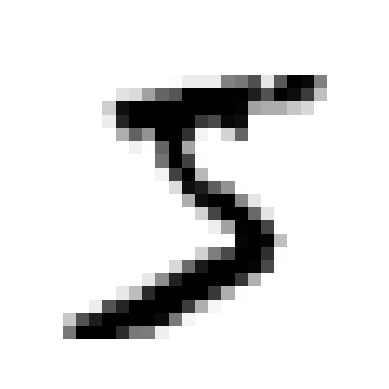

In [5]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap='binary')
    plt.axis('off')

some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [6]:
y[0]

'5'

In [7]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

## Training a Binary Classifier

Before tackling the full multiclass classification problem, we simplify the task to a binary classifier. We will train a model capable of distinguishing between two classes: "5" and "not-5".

We use a Stochastic Gradient Descent (SGD) classifier. This algorithm is highly efficient for large datasets because it processes training instances independently, making it perfectly suited for online learning systems.

In [9]:
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

In [21]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)
sgd_clf.predict([some_digit])

array([ True])